# Data Science Project - PrimeTrade.ai

# Objective
#### Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.


## Datasets

### 1) Bitcoin Market Sentiment (Fear/Greed)


### 2) Historical Trader Data (Hyperliquid)


# ------------------------------------------------------------------------------------

## A. Data Preparation

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
import warnings


In [67]:

warnings.filterwarnings("ignore")

#### Historical Trader Data

In [68]:
df_hist=pd.read_csv(r"C:\Users\DELL\Downloads\historical_data.csv")
print("Shape:",df_hist.shape)
df_hist.head()

Shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Bitcoin Market Sentiment Data

In [69]:
df_bit=pd.read_csv(r"C:\Users\DELL\Downloads\fear_greed_index.csv")
print("Shape:",df_bit.shape)
df_bit

Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


### Data Cleaning

In [70]:
print(df_hist.info())
print(df_bit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [71]:
# Extracting dates from timestamp in hist dataset
df_hist["date"] = pd.to_datetime(df_hist["Timestamp IST"],format="%d-%m-%Y %H:%M").dt.date
df_bit["date"] = pd.to_datetime(df_bit["date"]).dt.date
df_hist["date"] = pd.to_datetime(df_hist["date"])
df_bit["date"] = pd.to_datetime(df_bit["date"])
df_bit.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [72]:
df_hist["date"].head()

0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[ns]

In [73]:
#Checking for null values
print("Historical Trader Data")
print(df_hist.isnull().sum())
print("-----------------")
print("Bitcoin Market Sentiment")
print(df_bit.isnull().sum())

Historical Trader Data
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
-----------------
Bitcoin Market Sentiment
timestamp         0
value             0
classification    0
date              0
dtype: int64


Therefore there are no null values

### Metrics

In [74]:
#Merge
df = pd.merge(
    df_hist,
    df_bit[["date","classification"]],
    on="date",
    how="left"
)
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,Greed


In [75]:
df["classification"].isnull().sum()


np.int64(6)

In [76]:
df = df.dropna(subset=["classification"])

In [77]:
# Daily pnl per Trader
daily_pnl=df.groupby(["Account","date"])["Closed PnL"].sum().reset_index()
print("No of Traders: ",daily_pnl.shape[0])
print(daily_pnl)

No of Traders:  2340
                                         Account       date    Closed PnL
0     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11      0.000000
1     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17      0.000000
2     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18      0.000000
3     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22 -21227.000000
4     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26   1603.100000
...                                          ...        ...           ...
2335  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-27   1709.194807
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-28   4008.588908
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-29   8561.771838
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-30   2520.773814
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-05-01   1364.022527

[2340 rows x 3 columns]


In [78]:
#win rate
df["win"] = df["Closed PnL"] > 0
win_rate=df.groupby(["Account","date"])["win"].mean()

In [79]:
#avg size
avg_size = df.groupby(["Account","date"])["Size USD"].mean().reset_index(name="avg_size")
avg_size

,Account,date,avg_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,2153.859390
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,1495.538419
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,1939.739989
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,1748.805333


In [80]:
#trade count
trade_count = df.groupby(["Account", "date"]).size().reset_index(name="trade_count")
trade_count

,Account,date,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,82
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,430
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,902
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,75


In [81]:
#long ratio - proportion of BUY trades executed by a trader on a given day
df["is_long"] = df["Side"] == "BUY"
long_ratio = df.groupby(["Account", "date"])["is_long"].mean().reset_index()
long_ratio=long_ratio.rename(columns={"is_long":"long_ratio"})
long_ratio



,Account,date,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.609756
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.381395
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.478936
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.666667


In [82]:
#short ratio- proportion of SELL  trades executed by a trader on a given day
short_ratio = (
    1 - df.groupby(["Account","date"])["is_long"].mean()
).reset_index(name="short_ratio")
short_ratio

,Account,date,short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,1.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,1.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,1.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.555556
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.390244
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.618605
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.521064
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.333333


# Part -B Analysis

## Performance

In [83]:
daily_metrics = daily_pnl.merge(win_rate, on=["Account","date"])
daily_metrics = daily_metrics.merge(trade_count, on=["Account","date"])
daily_metrics = daily_metrics.merge(avg_size, on=["Account","date"])
daily_metrics = daily_metrics.merge(long_ratio, on=["Account","date"])
daily_metrics = daily_metrics.merge(df[["date", "classification"]].drop_duplicates(),on="date", how="left")
daily_metrics

,Account,date,Closed PnL,win,trade_count,avg_size,long_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,177,5089.718249,0.000000,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.000000,68,7976.664412,0.000000,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.000000,40,23734.500000,0.000000,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,0.000000,12,28186.666667,1.000000,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,0.444444,27,17248.148148,0.444444,Extreme Greed
...,...,...,...,...,...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,0.390244,82,2153.859390,0.609756,Greed
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,0.393023,430,1495.538419,0.381395,Neutral
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,0.441242,902,1939.739989,0.478936,Greed
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,0.520000,75,1748.805333,0.666667,Greed


In [84]:
# Performance
performance = daily_metrics.groupby("classification").agg({
    "Closed PnL": "mean",
    "win": "mean"
}).reset_index()

print(performance)

  classification   Closed PnL       win
0   Extreme Fear  4619.439053  0.329659
1  Extreme Greed  5161.922644  0.386387
2           Fear  5328.818161  0.364033
3          Greed  3318.100730  0.343559
4        Neutral  3438.618818  0.355414


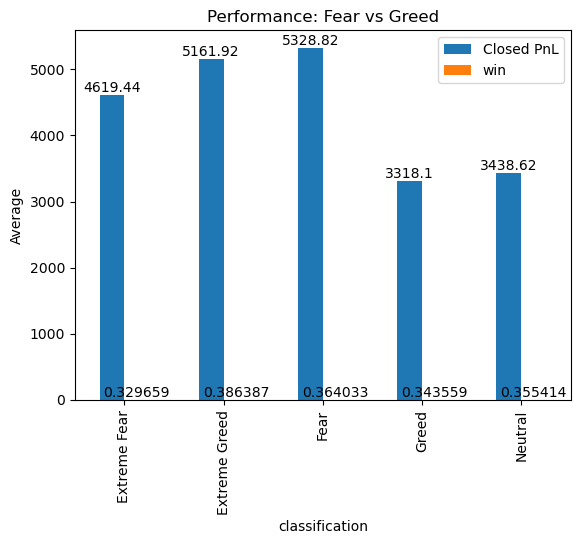

In [85]:
ax= performance.set_index("classification").plot(kind="bar")
plt.title("Performance: Fear vs Greed")
plt.ylabel("Average")
for bars in ax.containers:
    ax.bar_label(bars)


I observed that traders actually make more profit during Fear periods compared to Greed. This was a bit surprising because I initially expected higher profits during Greed. Even though the win rate is slightly higher in Greed, the total profit is still higher in Fear. This suggests that during Fear, traders might be making fewer but larger profitable trades

## Behavior 


In [86]:
behavior = daily_metrics.groupby("classification").agg({
    "trade_count": "mean",
    "avg_size": "mean",
    "long_ratio": "mean"
}).reset_index()

print(behavior)

  classification  trade_count     avg_size  long_ratio
0   Extreme Fear   133.750000  6773.464125    0.531533
1  Extreme Greed    76.030418  5371.637182    0.473116
2           Fear    98.153968  8975.928546    0.518967
3          Greed    77.628086  6427.866594    0.471594
4        Neutral   100.228723  6963.694861    0.472431


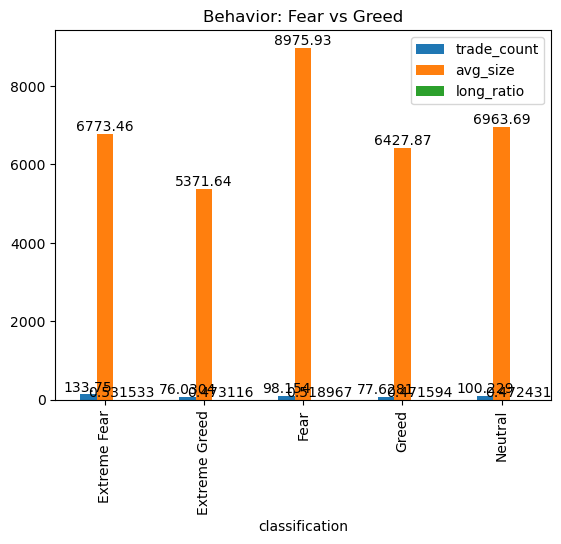

In [87]:
ax=behavior.set_index("classification").plot(kind="bar")
plt.title("Behavior: Fear vs Greed")
for bars in ax.containers:
    ax.bar_label(bars)

From the data, it looks like traders are more active during Fear periods, as the number of trades is higher. They also take larger position sizes during Fear, which means they are taking more risk. However, the long/short ratio does not change much, so `mtraders are not really changing their direction (buy or sell), but they are changing how much they trade and how much risk they take.

## Segmentation
##### Frequent vs Infrequent Traders


In [88]:
daily_metrics["freq_group"] = pd.qcut(
    daily_metrics["trade_count"], q=2,
    labels=["Low Activity", "High Activity"]
)

freq=daily_metrics.groupby("freq_group")["Closed PnL"].mean()
freq

freq_group
Low Activity     1221.728686
High Activity    7564.474676
Name: Closed PnL, dtype: float64

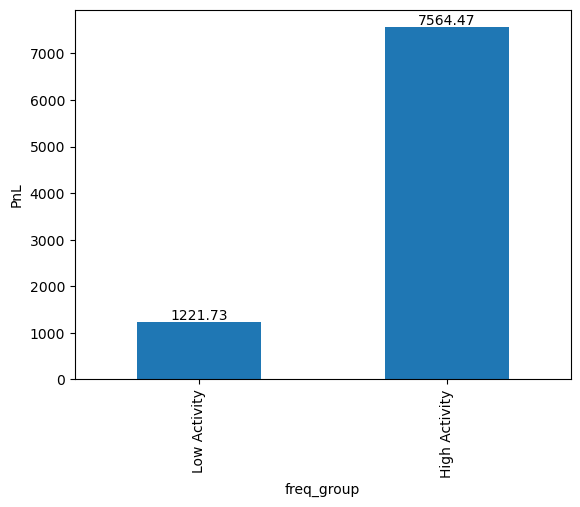

In [89]:
ax=freq.plot(kind="bar")
plt.ylabel("PnL")
for bars in ax.containers:
    ax.bar_label(bars)

##### Consistent vs Incosistent Traders

In [90]:
daily_metrics["consistency_group"] = pd.qcut(
    daily_metrics["win"], q=2,
    labels=["Low Consistency", "High Consistency"]
)

consis=daily_metrics.groupby("consistency_group")["Closed PnL"].mean()
consis

consistency_group
Low Consistency     -193.567826
High Consistency    8965.915204
Name: Closed PnL, dtype: float64

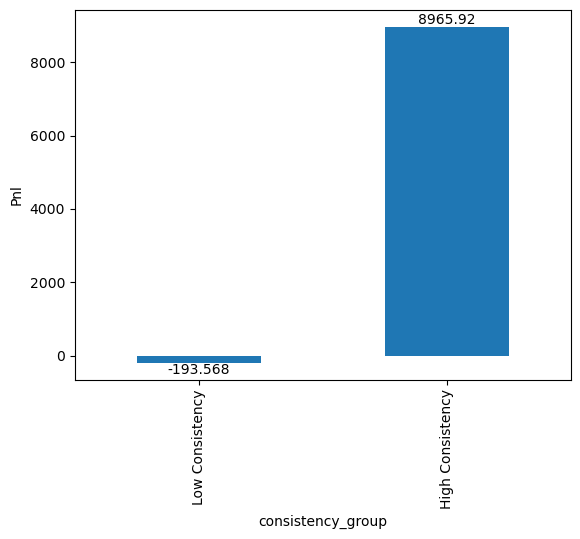

In [109]:
ax=consis.plot(kind="bar")
plt.ylabel("Pnl")
for bars in ax.containers:
    ax.bar_label(bars)

## Insights

1.From the performance plot, I observed that traders make higher profits during Fear periods compared to Greed. Even though win rate is slightly higher in Greed, overall profitability is better in Fear.

2.From the performance plot, I observed that traders make higher profits during Fear periods compared to Greed. Even though win rate is slightly higher in Greed, overall profitability is better in Fear.

3.From the behavior plot, traders are more active and take larger positions during Fear periods. This shows that traders take more risk during bearish market conditions.

## Actionable Outputs


### Strategy 1:Fear based Trading 
During Fear periods, traders tend to achieve higher profits while also taking larger positions.
Rule: Increase position size cautiously during Fear periods, as market volatility may provide better profit opportunities.

#### Strategy 2: Avoid Over Trading
During Fear periods, traders tend to achieve higher profits while also taking larger positions.
Rule: Increase position size cautiously during Fear periods, as market volatility may provide better profit opportunities.


## Predictive Model -1
Profit Bucket - Profit Bucket is just a way of grouping trades by how much profit or loss they made. In this case i have just categorized them into into two categories whether the trader is profitable(pNl)>0 or not .

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

daily_metrics["profit_bucket"] = (daily_metrics["Closed PnL"] > 0).astype(int)

X = daily_metrics[["trade_count", "avg_size", "long_ratio"]]
y = daily_metrics["profit_bucket"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



In [103]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6645299145299145


A simple logistic regression model was trained to predict whether a trader would be profitable based on behavioral features. The model achieved moderate accuracy, indicating that while these features provide some predictive signal, trader profitability is influenced by additional complex factors not captured in the dataset.

## Predictive Model -2 
Clustering traders into behavioral archetypes


In [104]:
features = daily_metrics[["trade_count", "avg_size", "long_ratio"]]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)



In [105]:

kmeans = KMeans(n_clusters=3, random_state=42)
daily_metrics["cluster"] = kmeans.fit_predict(features_scaled)


cluster_summary = daily_metrics.groupby("cluster").agg({
    "trade_count": "mean",
    "avg_size": "mean",
    "long_ratio": "mean",
    "Closed PnL": "mean"
}).reset_index()

cluster_summary

,cluster,trade_count,avg_size,long_ratio,Closed PnL
0,0,1.000000,844654.190000,0.000000,128.678290
1,1,120.423252,5518.422404,0.215343,5540.579194
2,2,51.554252,8055.502589,0.841338,2896.340227


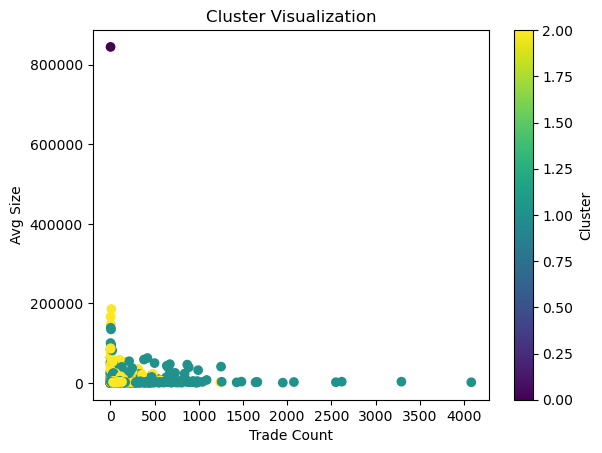

In [108]:
plt.scatter(
    daily_metrics["trade_count"],
    daily_metrics["avg_size"],
    c=daily_metrics["cluster"],
    cmap="viridis"
)

plt.xlabel("Trade Count")
plt.ylabel("Avg Size")
plt.title("Cluster Visualization")
plt.colorbar(label="Cluster")
plt.show()

The clustering visualization shows distinct groups of traders based on their activity and position size. Most traders have relatively small position sizes with varying trade frequencies. A small number of traders take very large positions, indicating high-risk behavior. The clusters suggest that traders can be categorized into different behavioral types such as high-frequency traders, low-frequency high-size traders, and balanced traders.

In [111]:
daily_metrics.to_csv(r"C:\Users\DELL\Downloads\Data Science Intern Project\daily_metrics.csv", index=False)